# Geometric sketching example using a PBMC dataset

2026.09.21

In [143]:
import warnings

import lightning.pytorch as pl
import scanpy as sc
import torch

from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.models import StreamingPlaidGeometricSketch, SingleCellVariationalInference
from cellarium.ml.utilities.data import AnnDataField, densify, categories_to_codes

sc.set_figure_params(fontsize=14, vector_friendly=True)

In [2]:
# download the data
!gsutil cp gs://cellarium-public/pbmc_count.h5ad /tmp/pbmc_count.h5ad

Copying gs://cellarium-public/pbmc_count.h5ad...
==> NOTE: You are downloading one or more large file(s), which would            
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

\ [1 files][218.5 MiB/218.5 MiB]                                                
Operation completed over 1 objects/218.5 MiB.                                    


In [3]:
# optional (total!) cleanup of old runs

!rm -r lightning_logs/

# Run geometric sketching

In `cellarium-ml`, geometric sketching (Hie et al. 2019, Cell Systems) has been re-implemented as a one-pass model. This makes it far more scalable than the original implementation. 

Here you could, for example, sketch a 100M cell dataset down to a representative 1M cells. This would be very difficult with the original, but is the main intended use case here.

The trade-off here is that the target number of cells is more approximate. This implementation also allows filtering of voxels (sketched regions) based on metadata thresholds (for exmaple, you can leave out regions where only one dataset has coverage if you desire, which could be useful for atlas-scale data where QC is not uniformly guaranteed).

In [80]:
# set up datamodule

adata = sc.read_h5ad("/tmp/pbmc_count.h5ad")

datamodule = CellariumAnnDataDataModule(
    dadc=adata,
    batch_keys={
        "x_ng": AnnDataField(
            attr="X", 
            convert_fn=densify,
        ),
        "var_names_g": AnnDataField(attr="var_names"),
        "obs_names_n": AnnDataField(attr="obs_names"),
        "batch_index_n": AnnDataField(
            attr="obs",
            key="batch",
            convert_fn=categories_to_codes,
        ),
    },
    batch_size=1024,
    shuffle=True,
)

In [ ]:
# train an scVI model

n_latent = 10

hidden_dim = 512
hidden_layers = [
    {
        "class_path": "cellarium.ml.models.scvi.LinearWithBatch",
        "init_args": {"out_features": hidden_dim, "label_to_bias_hidden_layers": []},
    },
]
final_layer = {
    "class_path": "cellarium.ml.models.scvi.LinearWithBatch",
    "init_args": {"label_to_bias_hidden_layers": []},
}

scvi_module = CellariumModule(
    model=SingleCellVariationalInference(
        var_names_g=datamodule.dadc.var_names,
        n_latent=n_latent,
        n_batch=datamodule.dadc.obs["batch"].nunique(),
        encoder={
            "hidden_layers": hidden_layers,
            "final_layer": final_layer,
        },
        decoder={
            "hidden_layers": hidden_layers,
            "final_layer": final_layer,
            "final_additive_bias": False,
        },
        batch_embedded=True,
        batch_representation_sampled=True,
        n_latent_batch=None,
        batch_kl_weight_max=0.01,
        kl_warmup_epochs=20,
        log_variational=True,
        normalizetotal_variational=True,
        input_gene_dropout_rate=0.1,
    ),
    optim_fn=torch.optim.AdamW,
    optim_kwargs={"lr": 1e-3},
)

datamodule.setup(stage="fit")

trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    max_epochs=63,
    default_root_dir="tmp/embedding",
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    trainer.fit(scvi_module, datamodule)

Dropout is not supported in the decoder of scVI. dropout_rate is being set to 0.0 in all decoder hidden layers.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 4.2 M  | train
-------------------------------------------------------
4.2 M     Trainable params
0         Non-trainable params
4.2 M     Total params
16.672    Total estimated model params size (MB)
37        Modules in train mode
0         Modules in eval mode


Epoch 62: 100%|██████████| 32/32 [00:01<00:00, 27.93it/s, v_num=1]

`Trainer.fit` stopped: `max_epochs=63` reached.


Epoch 62: 100%|██████████| 32/32 [00:01<00:00, 26.49it/s, v_num=1]


In [136]:
# train geometric sketching model, i.e. compute the sketch

sketch_module = CellariumModule(
    transforms=[
        scvi_module,
    ],
    model=StreamingPlaidGeometricSketch(
        var_names_g=[f"scvi_{i}" for i in range(n_latent)],
        target_voxels=10000,
        min_cells_per_voxel=2,
    )
)

datamodule.setup(stage="fit")

trainer = pl.Trainer(
    accelerator="cpu",
    devices=1,
    # max_epochs=1,
    default_root_dir="tmp/sketch",
)
trainer.fit(sketch_module, datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
------------

/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/sfleming/Documents/Github/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/Users/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure t

Epoch 0: 100%|██████████| 32/32 [00:01<00:00, 21.64it/s, v_num=26, current_cells=8933.0, voxel_size=1.600, active_voxels=8933.0, proj_total_cells=8933.0]   


/Users/sfleming/Documents/Github/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(


In [137]:
# obtain the sketch

sketched_obs_names = sketch_module.model.get_reservoir(return_cell_data=False)["obs_names"]
len(sketched_obs_names)

3577

# Explore output

### Raw dataset

In [138]:
adata

AnnData object with n_obs × n_vars = 31774 × 4000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'condition', 'concat', 'cl_cell_type', 'cl_cell_type_ontology_term_id'
    uns: 'neighbors', 'umap', 'final_annotation_colors', 'batch_colors', 'chemistry_colors'
    obsm: 'X_scvi', 'X_umap', 'X_scvi_umap'
    obsp: 'distances', 'connectivities'

In [129]:
# add the scvi representation

predict_datamodule = CellariumAnnDataDataModule(
    dadc=adata,
    batch_keys={
        "x_ng": AnnDataField(
            attr="X", 
            convert_fn=densify,
        ),
        "var_names_g": AnnDataField(attr="var_names"),
        "obs_names_n": AnnDataField(attr="obs_names"),
        "batch_index_n": AnnDataField(
            attr="obs",
            key="batch",
            convert_fn=categories_to_codes,
        ),
    },
    batch_size=len(adata),
    shuffle=False,
)

predict_datamodule.setup(stage="predict")
batch = next(iter(predict_datamodule.predict_dataloader()))
scvi_latents = scvi_module(batch)

adata.obsm["X_scvi"] = scvi_latents["x_ng"].detach().numpy()

In [130]:
sc.pp.neighbors(adata, use_rep="X_scvi", n_neighbors=15, metric="euclidean", method="umap")
sc.tl.umap(adata)
adata.obsm["X_scvi_umap"] = adata.obsm["X_umap"].copy()

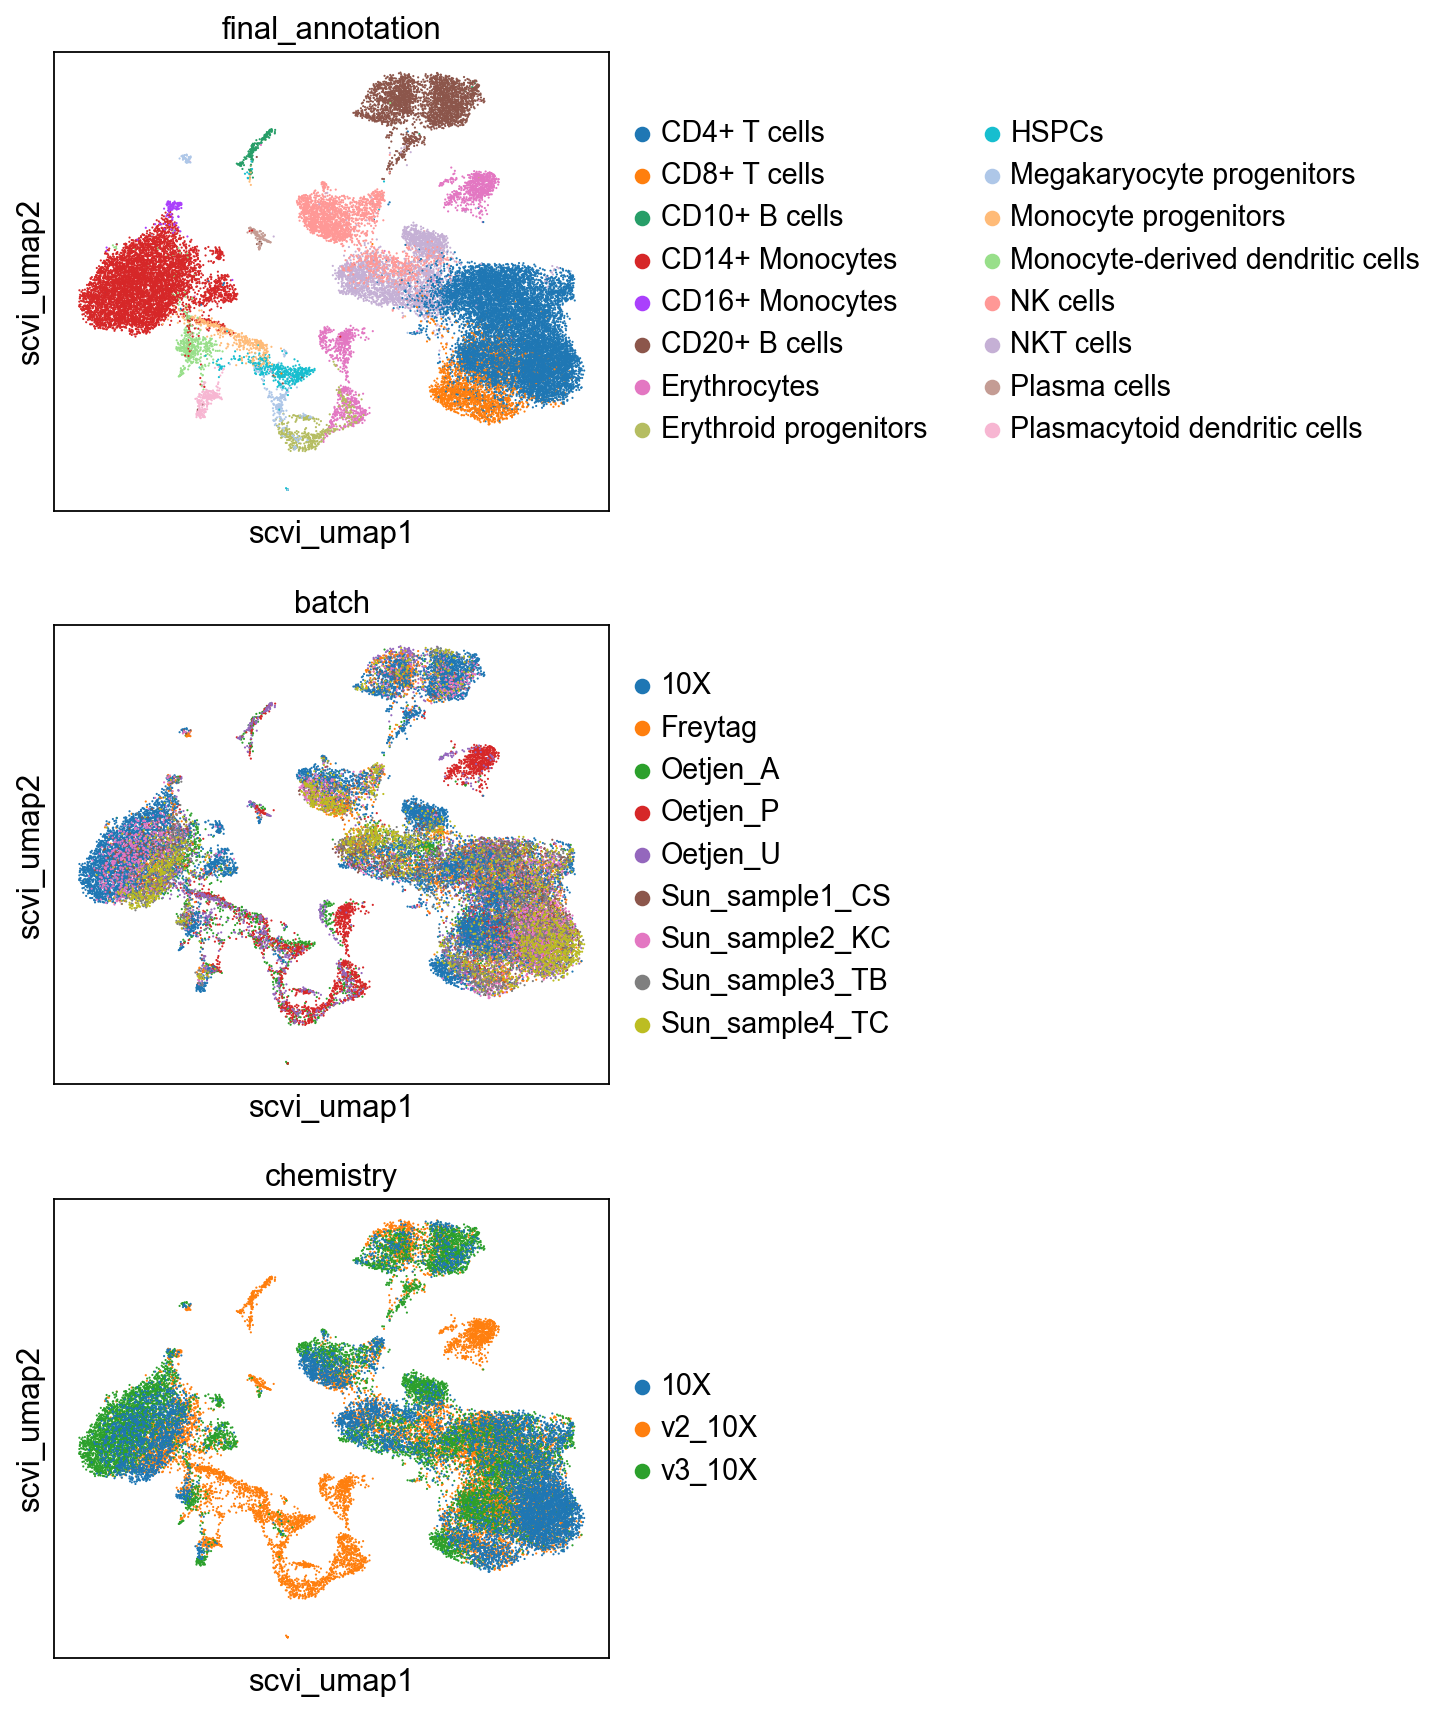

In [144]:
sc.pl.embedding(adata, basis="scvi_umap", color=["final_annotation", "batch", "chemistry"], ncols=1)

## Sketched dataset

In [139]:
adata_sketched = adata[sketched_obs_names].copy()
adata_sketched

AnnData object with n_obs × n_vars = 3577 × 4000
    obs: 'batch', 'chemistry', 'data_type', 'dpt_pseudotime', 'final_annotation', 'mt_frac', 'n_counts', 'n_genes', 'sample_ID', 'size_factors', 'species', 'study', 'tissue', 'condition', 'concat', 'cl_cell_type', 'cl_cell_type_ontology_term_id'
    uns: 'neighbors', 'umap', 'final_annotation_colors', 'batch_colors', 'chemistry_colors'
    obsm: 'X_scvi', 'X_umap', 'X_scvi_umap'
    obsp: 'distances', 'connectivities'

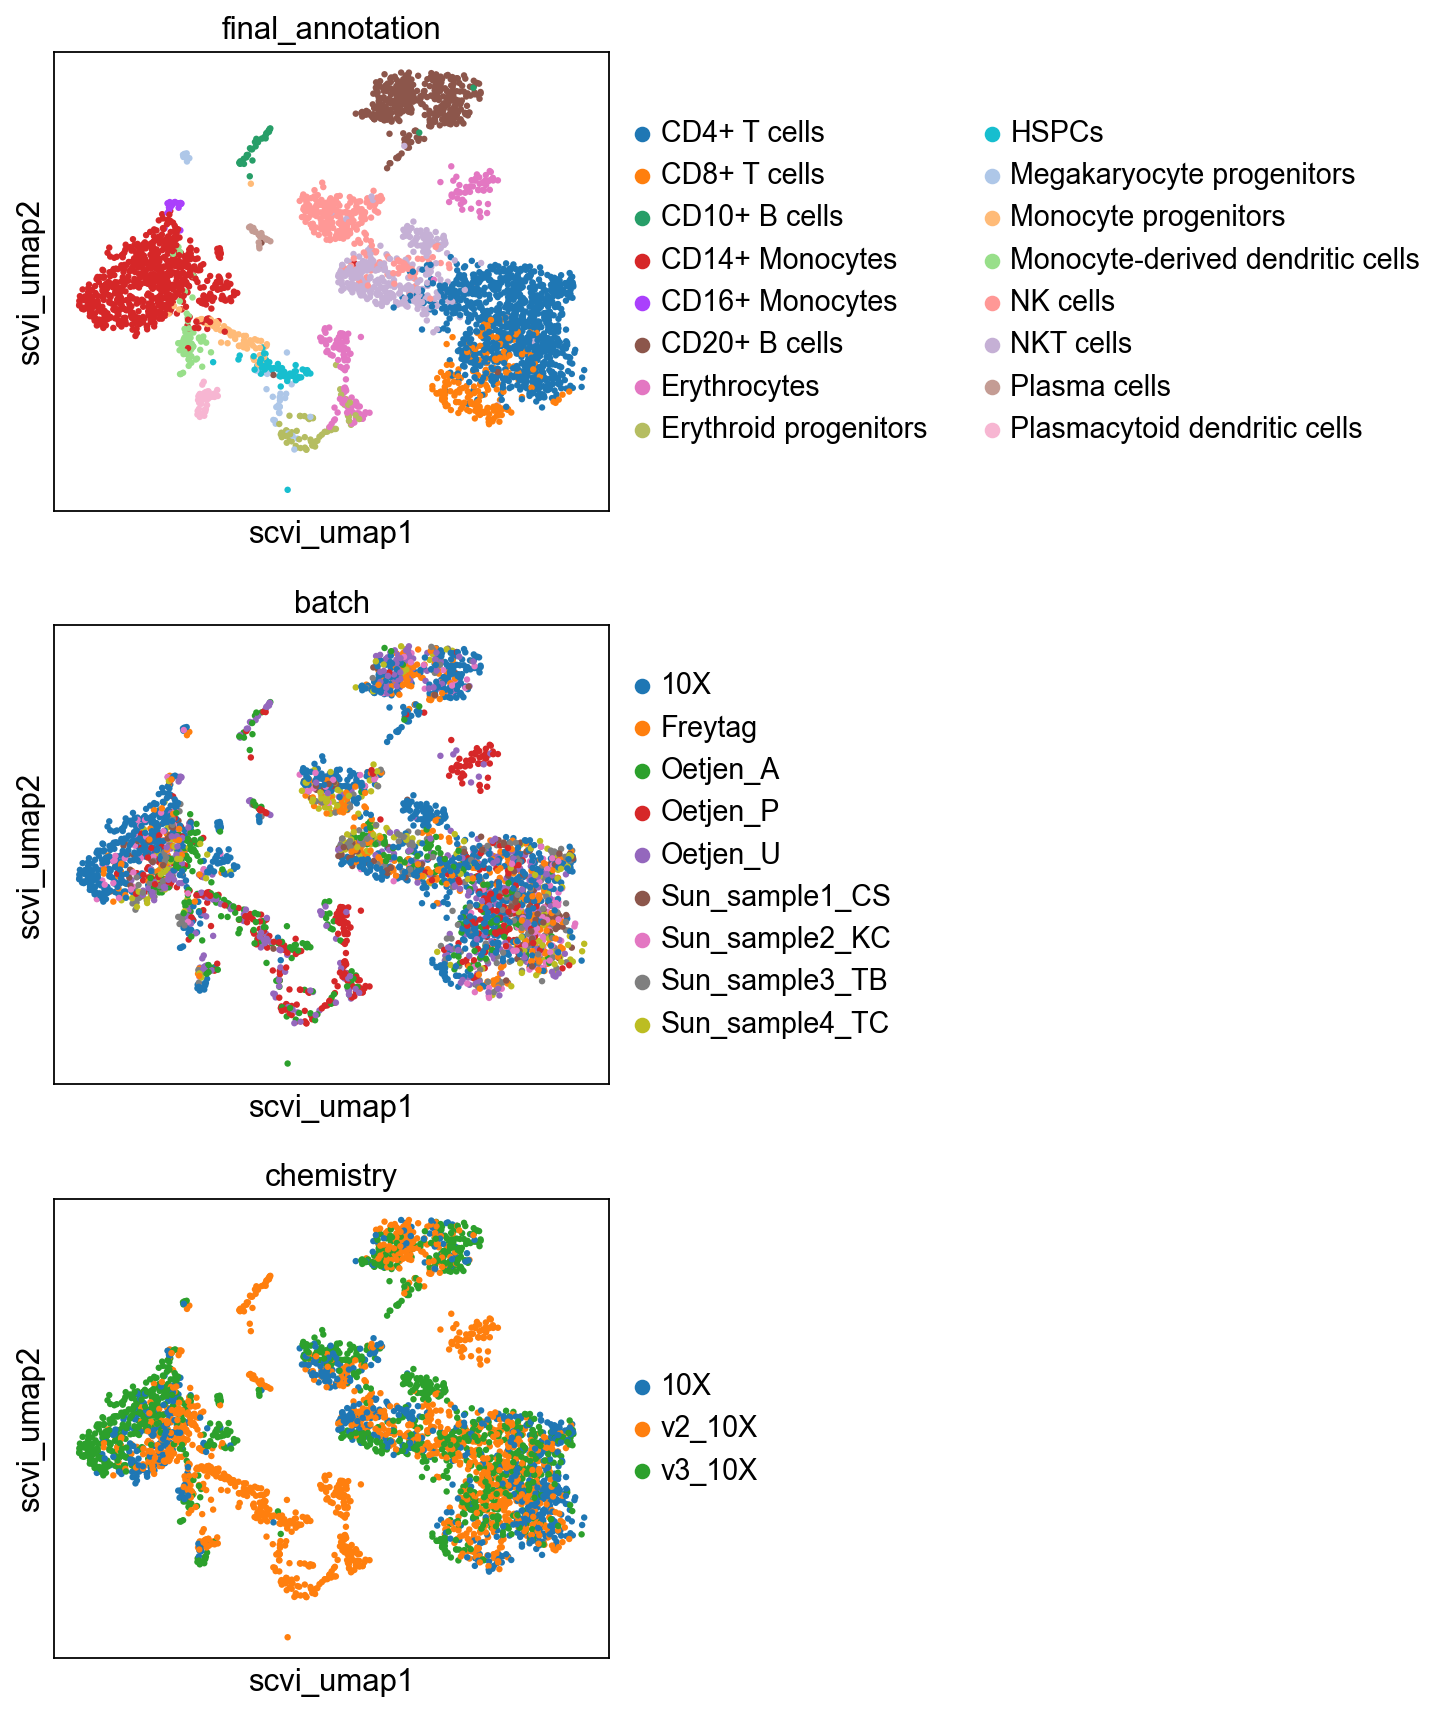

In [145]:
# kind of unfair, but this shows which cells are kept in the same UMAP representation as above

sc.pl.embedding(adata_sketched, basis="scvi_umap", color=["final_annotation", "batch", "chemistry"], ncols=1)

In [141]:
# this is more like what you would be able to compute using the sketch alone

sc.pp.neighbors(adata_sketched, use_rep="X_scvi", n_neighbors=15, metric="euclidean", method="umap")
sc.tl.umap(adata_sketched)
adata_sketched.obsm["X_scvi_sketched_umap"] = adata_sketched.obsm["X_umap"].copy()

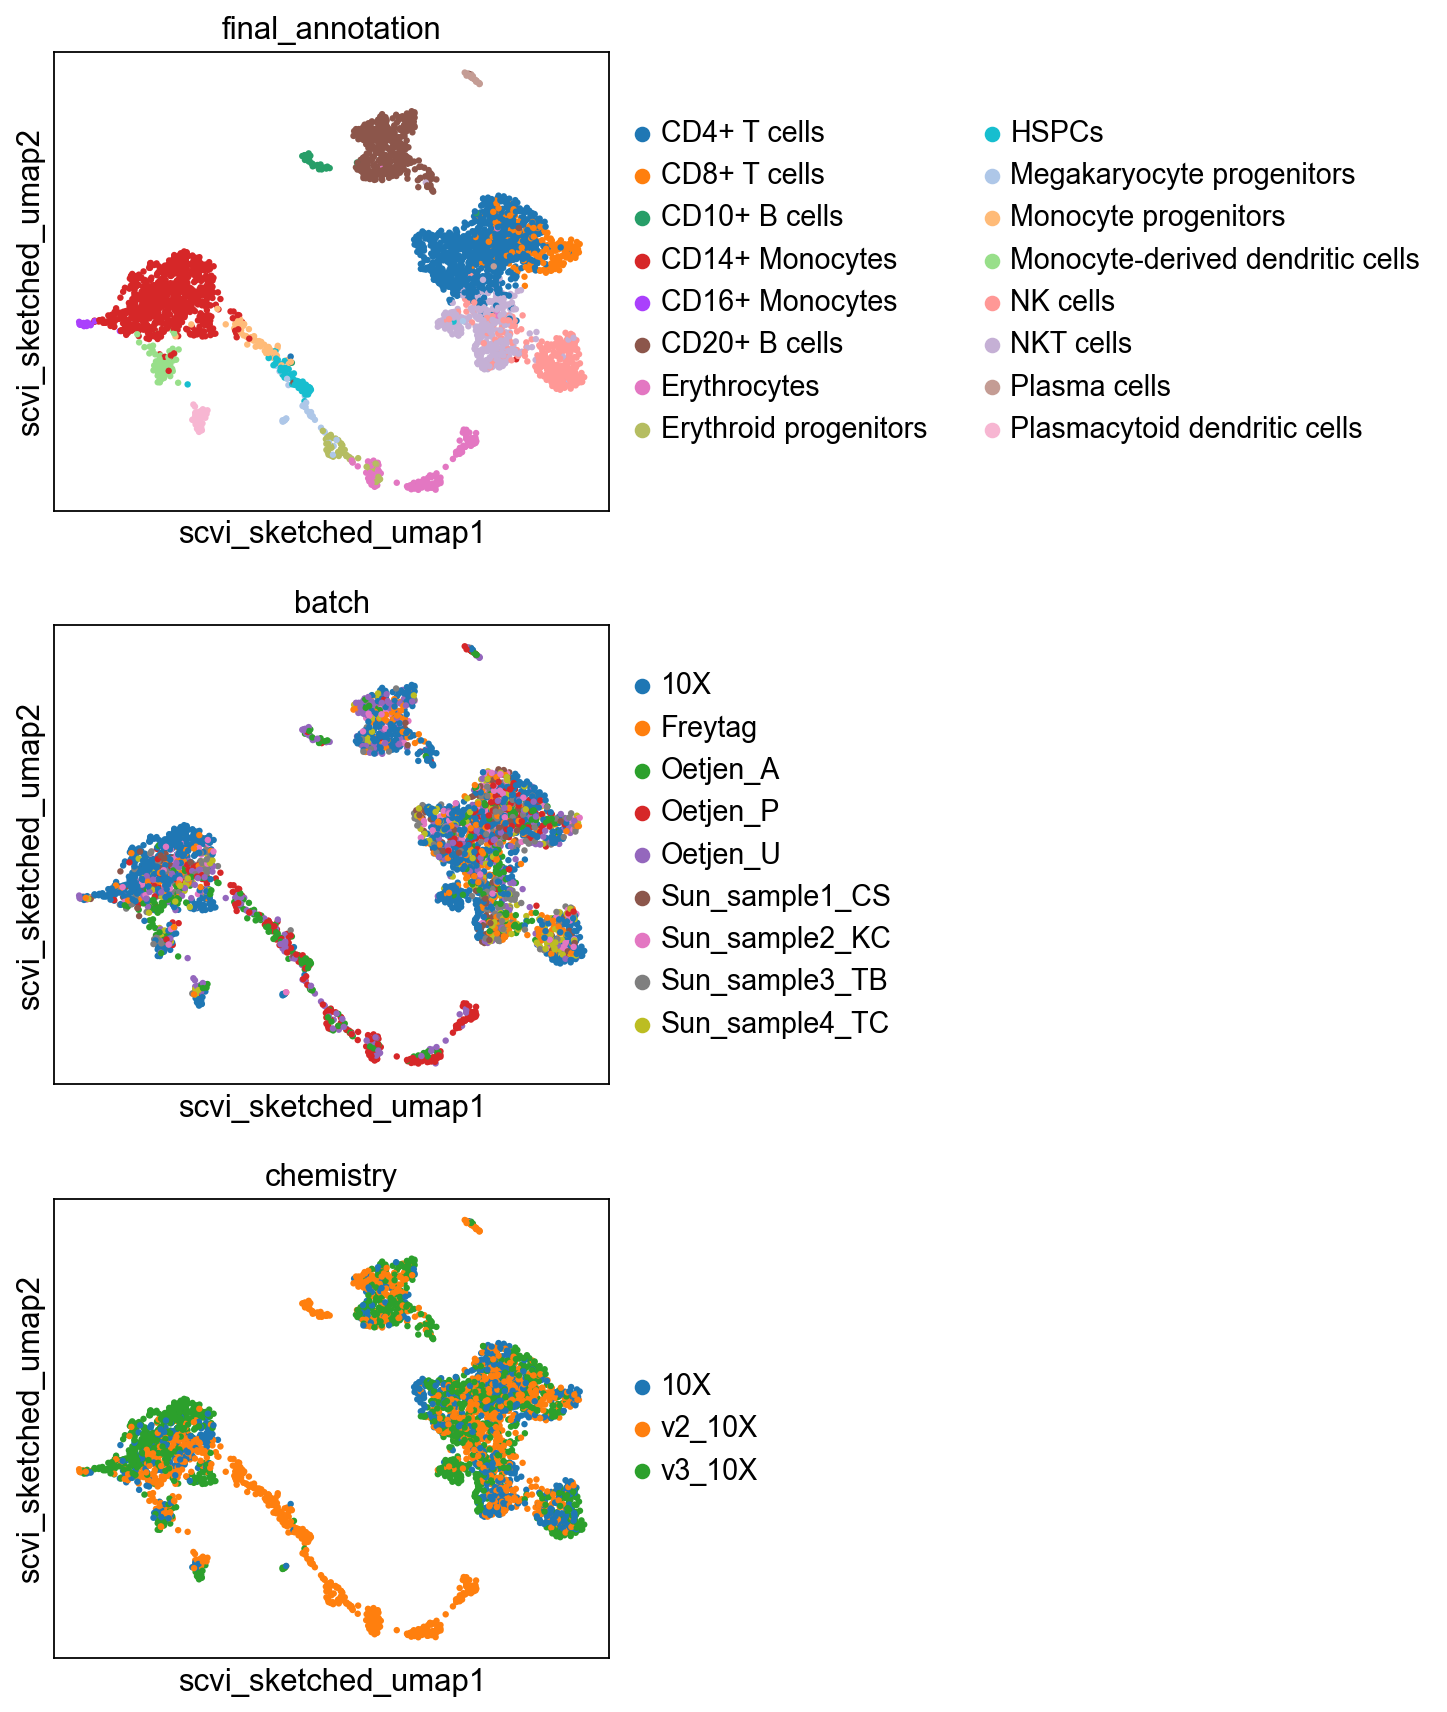

In [146]:
sc.pl.embedding(adata_sketched, basis="scvi_sketched_umap", color=["final_annotation", "batch", "chemistry"], ncols=1)